# Lab: Credit Card Customer Segmentation

ใช้ข้อมูลลูกค้าบัตรเครดิต 10,127 คน จากไฟล์ `CreditCardCustomer.csv` มาทำ Customer Segmentation ด้วย K-means Clustering
โดยหาจำนวนกลุ่มที่เหมาะสมที่สุด พร้อมทั้งอธิบายลักษณะของแต่ละกลุ่มที่ได้

# Preparation

* ใช้ DataFrame จาก pandas จัดการข้อมูล
* ใช้ KMeans จาก sklearn.cluster เพื่อทำ Clustering
* ใช้ StandardScaler ปรับสเกลข้อมูลก่อนเข้าโมเดล
* ใช้ Elbow Method ในการหาจำนวนกลุ่ม
* ใช้ Silhouette / DBI / CHI วัด Performance ของการจัดกลุ่ม

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from yellowbrick.cluster import KElbowVisualizer

## อ่านข้อมูลจากไฟล์ CSV
```
pd.read_csv()
```

In [3]:
df = pd.read_csv('CreditCardCustomer.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

## ตรวจสอบ missing values

In [5]:
df.isna().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

ไม่มีค่า NaN เลย แต่พอไปดูข้อมูลจริงจะเจอค่า `Unknown` แฝงอยู่ใน Education_Level, Marital_Status และ Income_Category
ในที่นี้จะถือว่า Unknown เป็นหมวดหนึ่งไปเลย ไม่ตัดทิ้งเพราะมีจำนวนเยอะพอสมควร

In [6]:
df['Education_Level'].value_counts()

Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

## เตรียมข้อมูล (Data Preparation)

* ตัด `CLIENTNUM` ออกเพราะเป็นแค่รหัสลูกค้า ไม่มีความหมายในการจัดกลุ่ม
* แยก `Attrition_Flag` เก็บไว้ก่อน ไม่เอาเข้าโมเดล แต่จะเอามาเทียบทีหลังว่ากลุ่มไหนลูกค้าเลิกใช้บัตรเยอะ

In [7]:
attrition = df['Attrition_Flag']
X = df.drop(columns=['CLIENTNUM', 'Attrition_Flag'])
X.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## Encoding

K-means คำนวณจากระยะห่างระหว่างจุด เลยต้องแปลงคอลัมน์ที่เป็นตัวหนังสือให้เป็นตัวเลขก่อน

* `Gender` → 0/1
* `Education_Level`, `Income_Category`, `Card_Category` → ordinal encoding เพราะมีลำดับตามธรรมชาติ (เช่น Blue < Silver < Gold < Platinum)
* `Marital_Status` → one-hot encoding ด้วย `pd.get_dummies()` เพราะไม่มีลำดับ

In [8]:
X['Gender'] = X['Gender'].map({'M': 0, 'F': 1})

edu_map = {'Unknown': 0, 'Uneducated': 1, 'High School': 2, 'College': 3,
           'Graduate': 4, 'Post-Graduate': 5, 'Doctorate': 6}
income_map = {'Unknown': 0, 'Less than $40K': 1, '$40K - $60K': 2,
              '$60K - $80K': 3, '$80K - $120K': 4, '$120K +': 5}
card_map = {'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}

X['Education_Level'] = X['Education_Level'].map(edu_map)
X['Income_Category'] = X['Income_Category'].map(income_map)
X['Card_Category'] = X['Card_Category'].map(card_map)

X = pd.get_dummies(X, columns=['Marital_Status'], dtype=int)
X.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,...,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown
0,45,0,3,2,3,0,39,5,1,3,...,11914.0,1.335,1144,42,1.625,0.061,0,1,0,0
1,49,1,5,4,1,0,44,6,1,2,...,7392.0,1.541,1291,33,3.714,0.105,0,0,1,0
2,51,0,3,4,4,0,36,4,1,0,...,3418.0,2.594,1887,20,2.333,0.000,0,1,0,0
3,40,1,4,2,1,0,34,3,4,1,...,796.0,1.405,1171,20,2.333,0.760,0,0,0,1
4,40,0,3,1,3,0,21,5,1,0,...,4716.0,2.175,816,28,2.500,0.000,0,1,0,0


## Scaling

สเกลของแต่ละคอลัมน์ต่างกันมาก เช่น `Credit_Limit` เป็นหลักหมื่น แต่ `Avg_Utilization_Ratio` อยู่แค่ 0-1
ถ้าไม่ปรับสเกล ระยะทางจะถูกคอลัมน์ตัวเลขใหญ่ๆ กลืนไปหมด เลยใช้ `StandardScaler` ปรับให้ทุกคอลัมน์ mean = 0, std = 1

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(10127, 22)

## Determining the number of clusters to be formed

* ใช้ Elbow Method ในการหาจำนวนกลุ่ม
```
KElbowVisualizer(KMeans(), k=(2, 11))
```

/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/

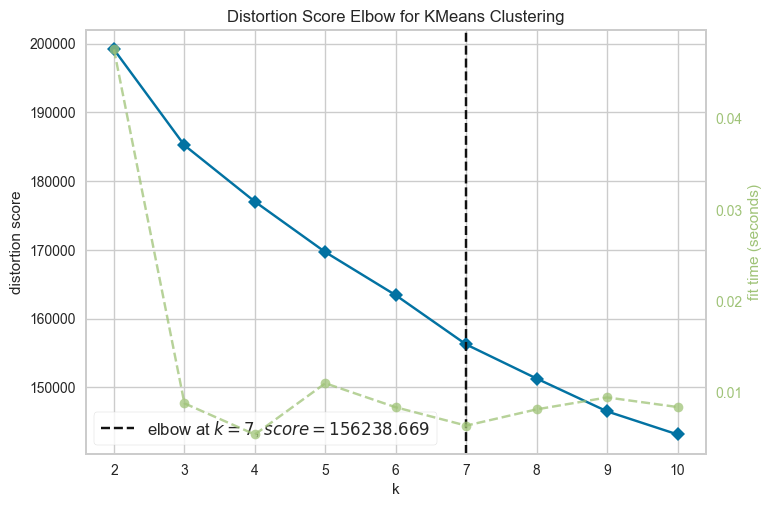

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
kelbow = KElbowVisualizer(KMeans(random_state=42, n_init='auto'), k=(2, 11), force_model=True)
kelbow.fit(X_scaled)
kelbow.show()

## Comparing Clustering Performance เพื่อเลือกค่า k ที่เหมาะสม

ลอง k = 2 ถึง 8 แล้วคำนวณคะแนนทั้ง 3 ตัวเทียบกัน
* Silhouette Score → ยิ่งสูงยิ่งดี
* Davies-Bouldin Index (DBI) → ยิ่งต่ำยิ่งดี
* Calinski-Harabasz Index (CHI) → ยิ่งสูงยิ่งดี

In [11]:
results = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)

    results.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels)
    })

pd.DataFrame(results).round(4)

/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/

,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.1497,2.5079,1201.1638
1,3,0.0935,2.7610,1026.6641
2,4,0.1002,2.5828,872.4000
3,5,0.0898,2.4383,792.1188
4,6,0.0921,2.6319,735.6507
5,7,0.0980,2.4380,718.4947
6,8,0.1021,2.3341,683.3908


**เลือก k = 7**

* Elbow Method ให้จุดหักที่ k = 7
* Silhouette สูงสุดที่ k = 2 ก็จริง แต่การแบ่งลูกค้าหมื่นคนเป็นแค่ 2 กลุ่มมันหยาบเกินไป เอาไปใช้ทำ segmentation จริงไม่ได้
* คะแนนโดยรวมของทุก k ค่อนข้างต่ำ (silhouette ~0.1) เพราะข้อมูลลูกค้าจริงมี 20 กว่ามิติและกลุ่มไม่ได้แยกขาดจากกันชัดๆ ซึ่งถือว่าปกติของข้อมูลแบบนี้
* เลยตัดสินใจใช้ k = 7 ตาม Elbow

## สร้างโมเดลของ k-means และให้โมเดลเรียนรู้จากข้อมูล
```
KMeans(n_clusters=7)
fit_predict()
```

In [12]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pattarapol/itkmitl/year3_term1/APPLIED/.venv/lib/

## Add the cluster labels to the original data

เอา label ไปแปะกับ DataFrame ตัวเดิม (ก่อน encode) เพื่อให้อ่านผลง่าย

In [13]:
df['cluster'] = labels
df.groupby('cluster').size()

cluster
0    1897
1    1500
2     953
3     677
4     730
5    2040
6    2330
dtype: int64

## ดูลักษณะของแต่ละกลุ่ม

ใช้ค่าเฉลี่ยของแต่ละคอลัมน์แยกตามกลุ่ม

In [14]:
df.groupby('cluster').mean(numeric_only=True).round(2).T

cluster,0,1,2,3,4,5,6
CLIENTNUM,7.389221e+08,7.396682e+08,7.391646e+08,7.404480e+08,7.375265e+08,7.397604e+08,7.387130e+08
Customer_Age,4.715000e+01,4.598000e+01,4.649000e+01,4.584000e+01,4.493000e+01,4.670000e+01,4.607000e+01
Dependent_count,2.250000e+00,2.240000e+00,2.620000e+00,2.550000e+00,2.270000e+00,2.410000e+00,2.290000e+00
Months_on_book,3.644000e+01,3.574000e+01,3.614000e+01,3.542000e+01,3.488000e+01,3.629000e+01,3.571000e+01
Total_Relationship_Count,4.040000e+00,4.060000e+00,3.490000e+00,3.860000e+00,2.200000e+00,4.040000e+00,3.890000e+00
Months_Inactive_12_mon,2.290000e+00,2.310000e+00,2.310000e+00,2.360000e+00,2.200000e+00,2.410000e+00,2.390000e+00
Contacts_Count_12_mon,2.380000e+00,2.470000e+00,2.520000e+00,2.430000e+00,2.150000e+00,2.580000e+00,2.470000e+00
Credit_Limit,3.440180e+03,8.618850e+03,3.071058e+04,7.329960e+03,1.070152e+04,7.761510e+03,4.328900e+03
Total_Revolving_Bal,1.670210e+03,1.066410e+03,1.184030e+03,1.161520e+03,1.395150e+03,7.238900e+02,1.114970e+03
Avg_Open_To_Buy,1.769970e+03,7.552440e+03,2.952654e+04,6.168440e+03,9.306370e+03,7.037620e+03,3.213930e+03


In [15]:
# ดูคอลัมน์ที่เป็นหมวดหมู่ด้วย ว่าแต่ละกลุ่มส่วนใหญ่เป็นใคร
cat_cols = ['Gender', 'Marital_Status', 'Income_Category', 'Card_Category']
df.groupby('cluster')[cat_cols].agg(lambda s: s.mode()[0])

,Gender,Marital_Status,Income_Category,Card_Category
cluster,,,,
0,F,Married,Less than $40K,Blue
1,M,Single,$60K - $80K,Blue
2,M,Single,$80K - $120K,Blue
3,F,Unknown,Less than $40K,Blue
4,M,Married,Less than $40K,Blue
5,M,Married,Less than $40K,Blue
6,F,Single,Less than $40K,Blue


## วาดกราฟ

ลอง plot ยอดใช้จ่ายรวมกับจำนวนครั้งที่รูดบัตร แยกสีตามกลุ่ม

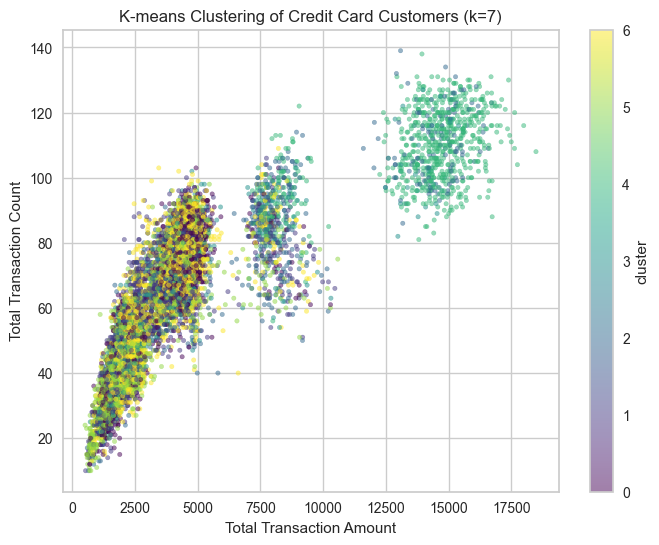

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Total_Trans_Amt'], df['Total_Trans_Ct'], c=df['cluster'], cmap='viridis', s=10, alpha=0.5)
plt.title('K-means Clustering of Credit Card Customers (k=7)')
plt.xlabel('Total Transaction Amount')
plt.ylabel('Total Transaction Count')
plt.colorbar(label='cluster')
plt.grid(True)
plt.show()

## เทียบผลกับ Attrition_Flag

ดูว่าแต่ละกลุ่มมีสัดส่วนลูกค้าที่เลิกใช้บัตร (Attrited Customer) เท่าไหร่

In [17]:
df.groupby('cluster')['Attrition_Flag'].apply(lambda s: (s == 'Attrited Customer').mean()).round(3)

cluster
0    0.073
1    0.163
2    0.170
3    0.177
4    0.016
5    0.250
6    0.189
Name: Attrition_Flag, dtype: float64

## สรุปผลการทำ Clustering

แบ่งลูกค้าออกเป็น 7 กลุ่ม 

| กลุ่ม | จำนวน | ลักษณะเด่น |
|---|---|---|
| 0 | 1,897 | แต่งงานแล้ว ส่วนใหญ่เป็นผู้หญิง รายได้น้อย วงเงินต่ำสุด (~3,400) แต่ใช้วงเงินหนักมาก |
| 1 | 1,500 | ผู้ชายโสดล้วน รายได้ปานกลาง-สูง วงเงิน ~8,600 ใช้จ่ายระดับกลางๆ |
| 2 | 953 | กลุ่มรายได้สูงสุด ถือบัตร Silver/Gold วงเงินสูงสุด (~30,700) แต่แทบไม่ใช้วงเงินเลย |
| 3 | 677 | กลุ่มที่สถานภาพสมรสเป็น Unknown ทั้งหมด ลักษณะอื่นกลางๆ |
| 4 | 730 | **ขาช้อปตัวจริง** ยอดใช้จ่ายสูงสุด (~13,600) รูดบัตรบ่อยสุด (~107 ครั้ง/ปี) แต่ถือผลิตภัณฑ์ของธนาคารน้อย |
| 5 | 2,040 | แต่งงานแล้ว ใช้บัตรน้อยที่สุด ทั้งยอดและจำนวนครั้ง (~54 ครั้ง/ปี) ยอดคงค้างต่ำ |
| 6 | 2,330 | ผู้หญิงโสดเกือบทั้งหมด รายได้น้อยที่สุด วงเงินต่ำ (~4,300) |

**ข้อสังเกตจาก Attrition Rate**

* กลุ่ม 5 มีอัตราลูกค้าเลิกใช้บัตรสูงสุดถึง **25%** สอดคล้องกับพฤติกรรมที่ใช้บัตรน้อยสุด → เป็นกลุ่มเสี่ยงที่ธนาคารควรทำโปรโมชั่นกระตุ้นการใช้งานก่อนที่ลูกค้าจะหายไป
* กลุ่ม 4 ขาช้อป เลิกใช้บัตรแค่ **1.6%** → ลูกค้าที่ใช้บัตรบ่อยแทบไม่หายไปไหน ยิ่ง active ยิ่ง loyal
* กลุ่ม 2 แม้จะรวยและวงเงินสูง แต่ utilization ต่ำมากและ attrition อยู่ที่ 17% → มีวงเงินแต่ไม่ค่อยได้ใช้ อาจต้องมีสิทธิพิเศษจูงใจให้ใช้บัตรมากขึ้น

สรุป พฤติกรรมการใช้บัตร (จำนวนครั้ง/ยอดใช้จ่าย) เป็นตัวแยกกลุ่มที่บอกความเสี่ยงลูกค้าหายได้ชัดกว่าข้อมูลส่วนตัวอย่างรายได้หรือวงเงิน